# SA - Time series txtfile creator
## Due to memory issues, this code creates rain timeseriers from rain radar data
## The file will be set as an input to the model during SA process

## Imports and files

In [1]:
import os
import pickle
import scipy.io as sio
import itertools

from datetime import datetime
from datetime import timedelta

import numpy as np
import pandas as pd
import geopandas as gpd

import contextily as ctx
from shapely.geometry import Polygon
from shapely.geometry import Point

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from rasterio.transform import from_origin
from collections import namedtuple

from swmm_api.input_file import read_inp_file, SwmmInput, section_labels as sections
from swmm_api import read_inp_file, read_out_file, swmm5_run

## Functions

In [2]:
def radar_array_to_gdf(rain_array, xll, yll, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.

    Parameters:
    - rain_array (numpy.ndarray): 2D array representing rainfall data.
    - xll (float): X-coordinate of the lower left corner of the grid.
    - yll (float): Y-coordinate of the lower left corner of the grid.
    - cellsize (float): Size of each cell in the grid.

    Returns:
    - radar_gdf (geopandas.GeoDataFrame): GeoDataFrame containing polygon geometries representing rainfall cells.

    This function takes a 2D array representing rainfall data and converts it into a GeoDataFrame with polygon geometries.
    Each cell in the array represents a rainfall value, and the function creates a polygon for each cell with its value
    as an attribute. The coordinate reference system is set to ITM (Israel Transverse Mercator).

    Note: The function adjusts the y-coordinate to handle the reversed north values. In the ITM coordinate system, the
    y-coordinate increases as you move south. Therefore, to align with the common representation of north-oriented grids,
    the function adjusts the y-coordinate calculation to ensure that the polygons are correctly positioned.
    """
    # Convert rainfall data to mm/hour
    rain_array = rain_array 
    
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Define transformation parameters
    transform = from_origin(xll, yll, cellsize, cellsize)
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Calculate y-coordinate
        y_coord = yll + (nrows - i - 1) * cellsize
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = xll + j * cellsize
            x_max = x_min + cellsize
            y_min = y_coord
            y_max = y_min - cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf

In [3]:
def create_TimeSeriesData_txt(basins_rain_df):
    """
    Update the TimeSeriesData values of SWMM inp file by using basins_rain_df.

    Args:
        basins_rain_df (DataFrame): DataFrame where each row represents a basin, and each column represents a timestep. 
                                    The values are rain (mm) for each basin in a timestep.
    Returns:
        str: Text representation of the updated timeseries data in the specified format.
    """
    # Initialize an empty string to store the text
    timeseries_text = ''
    # Write the header
    timeseries_text += ";;Name                 Date          Time         Value     \n"
    timeseries_text += ";;------------ ----------------- ------------- -------------\n"

    # Iterate over each row in the DataFrame
    for index, row in basins_rain_df.iterrows():
        # Get the basin name
        basin_name = int(row['Basin_name'])

        # Get the first timestamp to use it as the time series name
        first_timestamp = basins_rain_df.columns[1]  # the first timestamp column
        ts_name = first_timestamp.strftime('%Y%m%d') + f"_S{basin_name}"

        # Write the data to the text
        timestamps = basins_rain_df.columns[1:]  # excluding the first column 'Basin_name'
        values = row.values[1:]  # excluding the first column 'Basin_name'
        for ts, value in zip(timestamps, values):
            date_str = ts.strftime('%m/%d/%Y')
            time_str = ts.strftime('%H:%M:%S')
            timeseries_text += f"  {ts_name}      {date_str}    {time_str}   {value:.4f}\n"
        timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    
    return timeseries_text


In [4]:
def process_radar_data(rain_array_3d, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf):
    # First load the radar data

    rain_array_3d = rain_array_3d / 12  # Convert Units: mm/h to mm/5min
    rain_array_3d = rain_array_3d / BIAS  # Bias correction

    time_vector = radar_data['event_file'][0][0][1].ravel()
    time_vector = pd.to_datetime(time_vector - 719529, unit='D').round('1min')  # Convert the time from float to datetime and round
    time_steps = rain_array_3d.shape[-1]

    time_diff = time_vector[1:] - time_vector[:-1]
    is_5_min_interval = (time_diff == pd.Timedelta(minutes=5)).all()

    if not is_5_min_interval:
        raise ValueError("Time differences are not exactly 5 minutes. Please check the time vector.")

    radar_gdf_list = []

    for time in range(time_steps):
        rain_array_2d = rain_array_3d[:, :, time]
        radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        radar_indices = radar_intersecting_basins.index.unique()
        radar_filtered_gdf = radar_gdf.loc[radar_indices]
        radar_gdf_list.append(radar_filtered_gdf['rain_value'])

    radar_poly_grid_gdf = pd.concat(radar_gdf_list, axis=1)
    radar_poly_grid_gdf.columns = time_vector

    radar_poly_grid_gdf['geometry'] = radar_gdf['geometry']
    radar_poly_grid_gdf = gpd.GeoDataFrame(radar_poly_grid_gdf, crs='epsg:2039')
    radar_poly_grid_gdf.index.name = 'radar_cell_num'

    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[:])
    basins_rain_df = pd.DataFrame()
    for basin in range(1, len(raanana_basins_gdf) + 1):
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']]
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')
        weighted_avgs = []
        for col in basin_rain_columns[1:-1]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct'])
            weighted_avgs.append(weighted_avg)
        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns[:-1])
        basins_rain_df = pd.concat([basins_rain_df, df_basin])
    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0, inplace=True)

    resampled_dfs = []
    date = basins_rain_df.columns[1].strftime('%Y%m%d')  # Format date as YYYYMMDD
    
    return basins_rain_df

In [5]:
def BoxCoxTransform(rain_array, lam):
    """
    Apply Box-Cox transformation to rainfall data.
    Parameters:
    -----------
    rain_array : array_like -> Input array containing rainfall data.    
    lam : float -> Lambda parameter for transformation.
    Returns:
    --------
    trans_rain_array : numpy.ndarray -> Transformed rainfall data.    
    bias : float -> Bias factor for normalization.
    """
    
    # change nans values to 0
    rain_array = np.nan_to_num(rain_array, nan=0)
    # Perform Box-Cox transformation
    trans_rain_array = np.where(((rain_array**lam)-1) > 0, (((rain_array**lam)-1)/lam), 0)

    transformation_bias = trans_rain_array.sum() / rain_array.sum()

    # Normalize data to maintain total storm value
    trans_rain_array = trans_rain_array / transformation_bias
    
    return trans_rain_array, transformation_bias

In [6]:
def simpleTransform(rain_array, factor):
    """
    Apply linear transformation to rainfall data.
    Parameters:
    -----------
    rain_array : array_like -> Input array containing rainfall data.    
    lam : float -> Lambda parameter for transformation.
    Returns:
    --------
    trans_rain_array : numpy.ndarray -> Transformed rainfall data.    
    bias : float -> Bias factor for normalization.
    """
    
    # change nans values to 0
    rain_array = np.nan_to_num(rain_array, nan=0)
    # Perform Box-Cox transformation
    trans_rain_array = rain_array*factor

    transformation_bias = trans_rain_array.sum() / rain_array.sum()

    # Normalize data to maintain total storm value
#     trans_rain_array = trans_rain_array / transformation_bias
    
    return trans_rain_array, transformation_bias

## Load Data

In [7]:
# Load radar_basin_legend_gdf
directory = r"D:\Development\RESEARCH\Raanana\data\rain_radar\Basin_radar_overlap_pkl"
filename = "radar_basin_legend_gdf.pkl"
filepath = os.path.join(directory, filename)

with open(filepath, "rb") as f:
    radar_basin_legend_gdf = pickle.load(f)

In [8]:
# Load the shapefiles for Raanana
raanana_basins_shapfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_basins_gdf = gpd.read_file(raanana_basins_shapfile)  # sub-basins poly
raanana_basins_gdf.drop(columns=['Shape_Area', 'Area_km2', 'Area_ha','Area_m2'], inplace = True)

# Rain-Radar Transformation
## fromgrided matfile through transform basins rain txt file to inf file timeseries

In [9]:
# Load the storm MAT file
radar_dir = r'D:\Development\RESEARCH\Raanana\data\rain_radar\Row_radar_correct_MAT_files/'
EVENTS_AND_BIAS_L = [('20120113', 1.56),
    ('20160108', 1.24),
    ('20180125', 1.48),
    ('20191213', 0.79)]

metadata = {
    'xll': 179000,
    'yll': 648500,
    'cellsize': 500
}

## SELECT the storm event:
event_idx = 2
## Load rain array
filename_date = EVENTS_AND_BIAS_L[event_idx][0]
rain_gauge_bias = EVENTS_AND_BIAS_L[event_idx][1]
radar_data = sio.loadmat(radar_dir + filename_date)
# Rain Data
rain_array_3d= radar_data['event_file'][0][0][0]

# Create txt file using simple factor transormation
## multiply the rain field by a uniform factor

In [10]:
# directory path
directory_path = os.path.join(r"D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation", filename_date, "factor")
# Create the directory if it doesn't exist
os.makedirs(directory_path, exist_ok=True)

# Define the lam_factor values using np.arange
factors = np.arange(0.5, 1.5, 0.01)

# Loop through the lam_factor values
for factor in factors:
    # Round lam_factor to 2 digits after the decimal
    factor_rounded = round(factor, 2)

    # Define the file name using the formatted lam_factor value with 2 digits after the decimal
    file_name = f"transform_timeseries_data_factor_{factor_rounded:.2f}.txt"

    # Combine the directory path and file name to get the full file path
    file_path = os.path.join(directory_path, file_name)

    # Check if the file already exists
    if os.path.exists(file_path):
        print("File already exists, skipping:", file_path)
        continue  # Skip to the next iteration if the file exists

    # Perform Box-Cox transformation (placeholder function)
    trans_rain_array, transformation_bias = simpleTransform(rain_array_3d, factor=factor)

    # Calculate rain data using transformed rain array and BIAS (placeholder function)
    basins_rain_df = process_radar_data(trans_rain_array, raanana_basins_gdf, metadata, rain_gauge_bias, radar_basin_legend_gdf)
    # Create time series data text (placeholder function)
    transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)

    # Open the file in write mode and save the text data
    with open(file_path, "w") as text_file:
        text_file.write(transform_timeseries_text)

    print("Text data saved to:", file_path)


Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_0.50.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_0.51.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_0.52.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_0.53.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_0.54.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_0.55.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_1.03.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_1.04.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_1.05.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_1.06.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_1.07.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\factor\transform_timeseries_data_factor_1.08.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA

# Create txt file using coxbox transormation

In [11]:
# directory path
directory_path = os.path.join(r"D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation", filename_date, "CoxBox")
# Create the directory if it doesn't exist
os.makedirs(directory_path, exist_ok=True)

# Define the lam_factor values using np.arange
lam_factors = np.arange(0.2, 2, 0.01)

# Loop through the lam_factor values
for lam_factor in lam_factors:
    # Round lam_factor to 2 digits after the decimal
    lam_factor_rounded = round(lam_factor, 2)

    # Define the file name using the formatted lam_factor value with 2 digits after the decimal
    file_name = f"transform_timeseries_data_lam_{lam_factor_rounded:.2f}.txt"

    # Combine the directory path and file name to get the full file path
    file_path = os.path.join(directory_path, file_name)

    # Check if the file already exists
    if os.path.exists(file_path):
        print("File already exists, skipping:", file_path)
        continue  # Skip to the next iteration if the file exists

    # Perform Box-Cox transformation (placeholder function)
    trans_rain_array, transformation_bias = BoxCoxTransform(rain_array_3d, lam=lam_factor)

    # Calculate rain data using transformed rain array and BIAS (placeholder function)
    basins_rain_df = process_radar_data(trans_rain_array, raanana_basins_gdf, metadata, rain_gauge_bias, radar_basin_legend_gdf)
    # Create time series data text (placeholder function)
    transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)

    # Open the file in write mode and save the text data
    with open(file_path, "w") as text_file:
        text_file.write(transform_timeseries_text)

    print("Text data saved to:", file_path)


Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.20.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.21.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.22.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.23.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.24.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.25.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transf

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.74.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.75.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.76.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.77.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.78.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_0.79.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transf

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.28.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.29.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.30.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.31.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.32.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.33.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transf

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.82.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.83.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.84.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.85.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.86.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20180125\CoxBox\transform_timeseries_data_lam_1.87.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transf

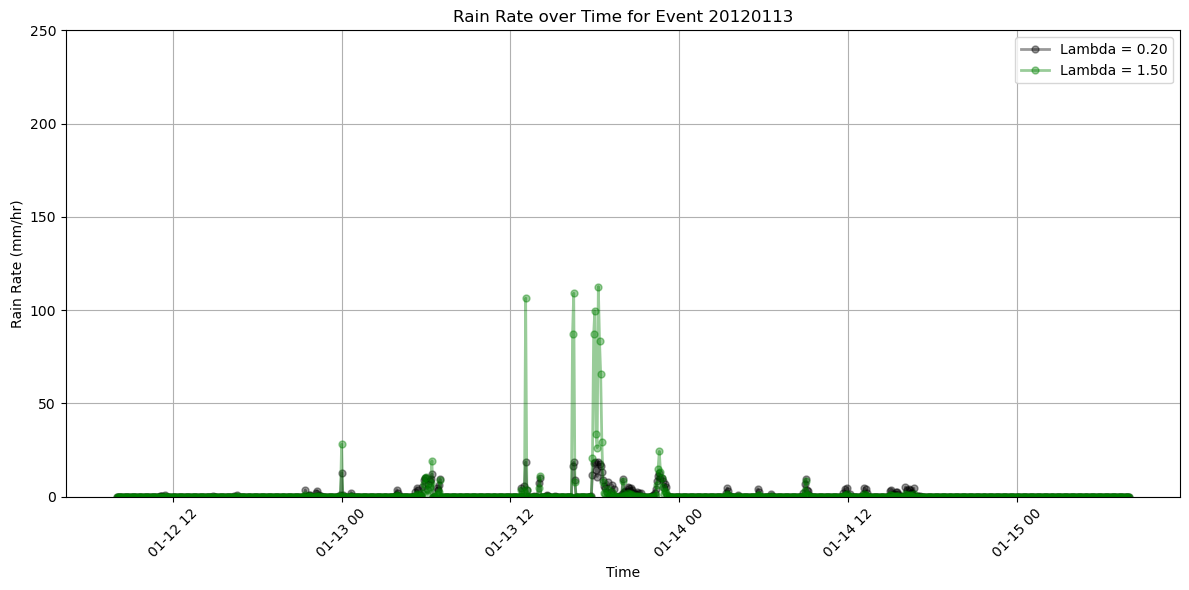

In [11]:
# Directory containing the rainfall timeseries files
base_dir = r"D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation"
event_date = "20120113"  # Replace this with the specific event date you want to plot
dir_path = os.path.join(base_dir, event_date, "CoxBox")

# List of lambda values you want to plot
lambdas_to_plot = [0.2, 1.50]  # You can add or remove values from this list
colors = {0.50: 'blue', 1.00: 'orange', 1.50: 'green'}  # Adjust colors if needed

# Initialize plot
plt.figure(figsize=(12, 6))

# Specify the name to plot, e.g., '20120112_S1'
name_to_plot = '20120112_S1'

# Loop over each lambda value and plot
for lam in lambdas_to_plot:
    # Format lambda to two decimal places
    filename = f"transform_timeseries_data_lam_{lam:.2f}.txt"
    file_path = os.path.join(dir_path, filename)
    
    # Check if file exists before attempting to read
    if not os.path.exists(file_path):
        print(f"File {filename} not found. Skipping...")
        continue
    
    # Load the data into a DataFrame
    data = pd.read_csv(file_path, delim_whitespace=True)
    
    # Clean up the column names (remove leading/trailing spaces and unwanted characters)
    data.columns = data.columns.str.replace('^;+', '', regex=True).str.strip()
    
    # Ensure 'Value' column is numeric and remove invalid values
    data['Value'] = pd.to_numeric(data['Value'], errors='coerce')
    
    # Filter data to include only rows for the specific name
    data_filtered = data[data['Name'] == name_to_plot]
    
    # Remove rows with invalid or non-date values in the 'Date' and 'Time' columns
    data_filtered = data_filtered[~data_filtered['Date'].str.contains('[-]+', na=False)]  # Remove rows with invalid date format

    # Ensure time column is in datetime format if it's split into date and time
    if 'Date' in data_filtered.columns and 'Time' in data_filtered.columns:
        try:
            data_filtered['Timestamp'] = pd.to_datetime(data_filtered['Date'] + ' ' + data_filtered['Time'])
        except Exception as e:
            print(f"Error converting to datetime for {filename}: {e}")
            continue
    elif 'Timestamp' in data_filtered.columns:
        try:
            data_filtered['Timestamp'] = pd.to_datetime(data_filtered['Timestamp'])
        except Exception as e:
            print(f"Error converting 'Timestamp' for {filename}: {e}")
            continue
    
    # Convert the rain rate from mm/5min to mm/hr
    data_filtered['Value'] = data_filtered['Value'] * 12
    
    # Plot the rain rate with markers and lines, add line styles and markers
    plt.plot(data_filtered['Timestamp'], data_filtered['Value'], label=f'Lambda = {lam:.2f}', 
             color=colors.get(lam, 'black'), linestyle='-', marker='o', markersize=5, alpha=0.4, linewidth=2)

# Customize plot
plt.xlabel('Time')
plt.ylabel('Rain Rate (mm/hr)')
plt.title(f'Rain Rate over Time for Event {event_date}')
plt.legend()
plt.grid()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Set the Y-axis range and labels
plt.ylim(0, 150)
plt.yticks(range(0, 251, 50))  # Y-axis labels between 0 and 150, in intervals of 50

# Show the plot with tight layout
plt.tight_layout()
plt.show()
